In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Kaggle train.csv
df = pd.read_csv("train.csv")

print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (10886, 12)
              datetime  season  holiday  workingday  weather  temp   atemp  \
0  2011-01-01 00:00:00       1        0           0        1  9.84  14.395   
1  2011-01-01 01:00:00       1        0           0        1  9.02  13.635   
2  2011-01-01 02:00:00       1        0           0        1  9.02  13.635   
3  2011-01-01 03:00:00       1        0           0        1  9.84  14.395   
4  2011-01-01 04:00:00       1        0           0        1  9.84  14.395   

   humidity  windspeed  casual  registered  count  
0        81        0.0       3          13     16  
1        80        0.0       8          32     40  
2        80        0.0       5          27     32  
3        75        0.0       3          10     13  
4        75        0.0       0           1      1  


In [4]:

# Feature engineering
df["datetime"] = pd.to_datetime(df["datetime"])
df["year"] = df["datetime"].dt.year
df["month"] = df["datetime"].dt.month
df["day"] = df["datetime"].dt.day
df["hour"] = df["datetime"].dt.hour
df["weekday"] = df["datetime"].dt.weekday

features = [
    "season", "holiday", "workingday", "weather",
    "temp", "atemp", "humidity", "windspeed",
    "year", "month", "day", "hour", "weekday"
]

X = df[features]
y = df["count"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)


In [5]:

def evaluate(name, actual, predicted):
    predicted = np.maximum(predicted, 0)
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)
    rmsle = np.sqrt(np.mean((np.log1p(actual) - np.log1p(predicted)) ** 2))
    return [name, mae, rmse, r2, rmsle]



In [6]:
# 1. Decision Tree
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# 2. Bagging - Random Forest
rf = RandomForestRegressor(
    n_estimators=100, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# 3. Boosting - AdaBoost
ada = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),
    n_estimators=100,
    random_state=42
)
ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

# 4. Stacking
base_models = [
    ("decision_tree", DecisionTreeRegressor(max_depth=8, random_state=42)),
    ("random_forest", RandomForestRegressor(
        n_estimators=50, random_state=42, n_jobs=-1
    )),
    ("adaboost", AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=4),
        n_estimators=50,
        random_state=42
    ))
]

stack = StackingRegressor(
    estimators=base_models,
    final_estimator=LinearRegression()
)
stack.fit(X_train, y_train)
stack_pred = stack.predict(X_test)



<ipython-input-8-cabe878543eb>:19: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  plt.savefig("results/model_comparison.png")
<ipython-input-8-cabe878543eb>:19: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.savefig("results/model_comparison.png")


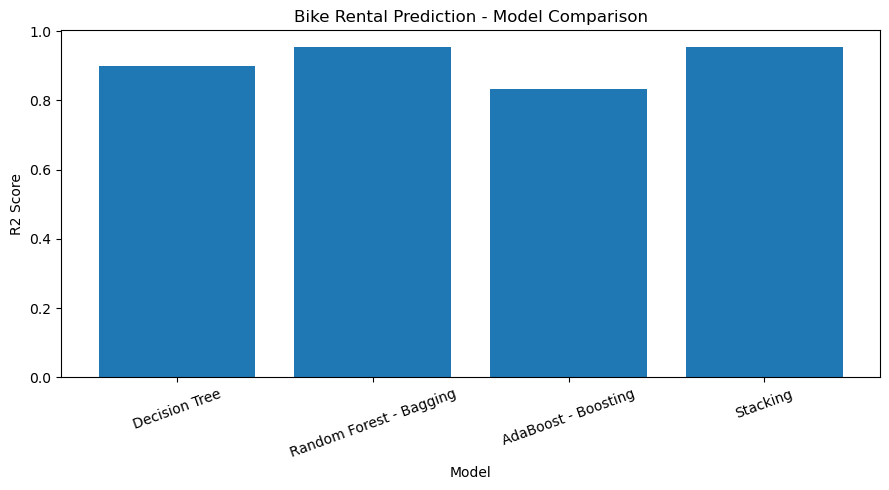


FILES SAVED SUCCESSFULLY
1. results/model_comparison.csv
2. results/model_comparison.png
3. results/predictions.csv


In [8]:

import os

os.makedirs("results", exist_ok=True)



plt.figure(figsize=(9, 5))

plt.bar(results["Model"], results["R2"])

plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Bike Rental Prediction - Model Comparison")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig("results/model_comparison.png")

plt.show()


results.to_csv(
    "results/model_comparison.csv",
    index=False
)



predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.maximum(stack_pred, 0)
})

predictions.to_csv(
    "results/predictions.csv",
    index=False
)


print("\n==========================================")
print("FILES SAVED SUCCESSFULLY")
print("==========================================")

print("1. results/model_comparison.csv")
print("2. results/model_comparison.png")
print("3. results/predictions.csv")

<ipython-input-9-b5241559c2bd>:9: MatplotlibDeprecationWarning: The x parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(x) instead.
  plt.savefig("results/model_comparison.png")
<ipython-input-9-b5241559c2bd>:9: MatplotlibDeprecationWarning: The y parameter as float was deprecated in Matplotlib 3.10 and will be removed in 3.12. Use int(y) instead.
  plt.savefig("results/model_comparison.png")


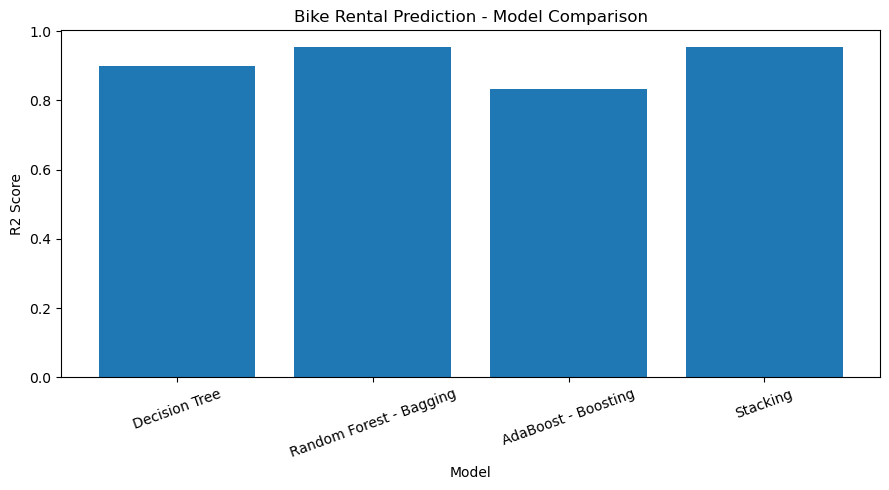


Results saved in the results/ folder.


In [9]:

# R2 graph
plt.figure(figsize=(9, 5))
plt.bar(results["Model"], results["R2"])
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Bike Rental Prediction - Model Comparison")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("results/model_comparison.png")
plt.show()

# Save sample predictions
predictions = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.maximum(stack_pred, 0)
})
predictions.to_csv("results/predictions.csv", index=False)

print("\nResults saved in the results/ folder.")
